In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()
# Yahan kaggle.json select karo apne laptop se
# Sirf yeh ek file upload karni hai, dataset nahi

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ameerhamza2005","key":"7092d246b0407bce93d6afb5f4ba9f9c"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Dataset directly Colab mein download
!kaggle competitions download -c GiveMeSomeCredit
!unzip -q GiveMeSomeCredit.zip
!ls  # check karo files aa gayi hain

100% 5.16M/5.16M [00:01<00:00, 3.46MB/s]

 cs-test.csv	  'Data Dictionary.xls'   kaggle.json   sampleEntry.csv
 cs-training.csv   GiveMeSomeCredit.zip   sample_data


In [4]:
import pandas as pd
df = pd.read_csv('cs-training.csv', index_col=0)
print(df.shape)
print(df.head())

(150000, 11)
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
1                 1                              0.766127   45   
2                 0                              0.957151   40   
3                 0                              0.658180   38   
4                 0                              0.233810   30   
5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
1                                     2   0.802982         9120.0   
2                                     0   0.121876         2600.0   
3                                     1   0.085113         3042.0   
4                                     0   0.036050         3300.0   
5                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
1                               13                        0   
2                                4               

In [5]:
!pip install imbalanced-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import joblib

print("✅ All libraries imported!")

✅ All libraries imported!


In [7]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Total missing: 33655


Target Distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default Rate: 6.68%


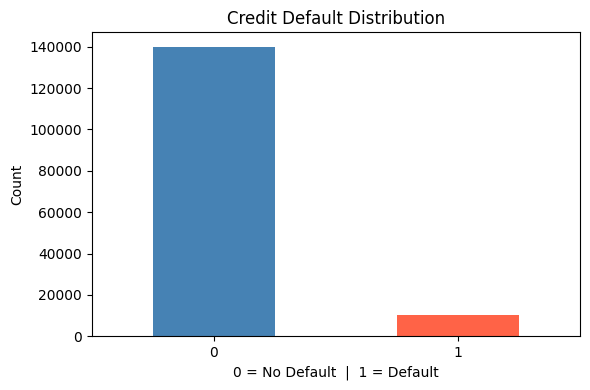

In [8]:
print("Target Distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault Rate: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

plt.figure(figsize=(6,4))
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar',
                                            color=['steelblue','tomato'])
plt.title('Credit Default Distribution')
plt.xlabel('0 = No Default  |  1 = Default')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Target Distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default Rate: 6.68%


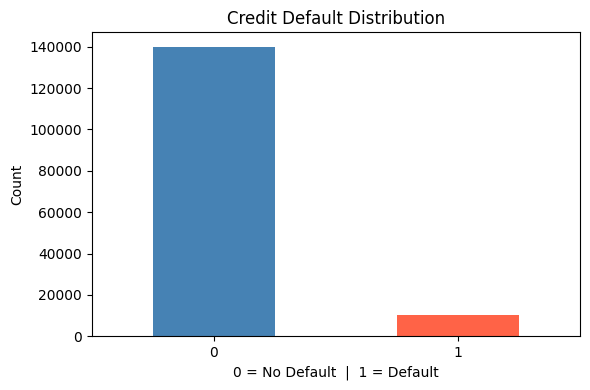

In [9]:
print("Target Distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault Rate: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

plt.figure(figsize=(6,4))
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar',
                                            color=['steelblue','tomato'])
plt.title('Credit Default Distribution')
plt.xlabel('0 = No Default  |  1 = Default')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Missing values fill karo median se
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Verify
print("Missing values after fix:")
print(df.isnull().sum().sum())  # 0 hona chahiye

# Feature Engineering
df['DebtIncomeRatio'] = df['DebtRatio'] * df['MonthlyIncome']
df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=df['MonthlyIncome'].quantile(0.99))
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

print(f"✅ Missing values fixed!")
print(f"✅ Feature engineering done!")
print(f"New shape: {df.shape}")

Missing values after fix:
0
✅ Missing values fixed!
✅ Feature engineering done!
New shape: (150000, 12)


In [11]:
# Features aur Target alag karo
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Class weight calculate karo automatically
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"\n✅ Class Weights: {class_weight_dict}")
# Default walo ka weight kam, Default walo ka zyada

# Train/Test Split (original data pe)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

X shape: (150000, 11)
y shape: (150000,)

✅ Class Weights: {0: np.float64(0.5358137939903125), 1: np.float64(7.480550568521843)}

✅ Split done!
Training samples : 120000
Testing  samples : 30000


In [12]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling done!")

# 3 Models train karo class_weight ke saath
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight=class_weight_dict
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, random_state=42,
        class_weight=class_weight_dict
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42,
        class_weight=class_weight_dict,
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():
    print(f"⏳ Training {name}...")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✅ {name} done!")

✅ Scaling done!
⏳ Training Logistic Regression...
✅ Logistic Regression done!
⏳ Training Decision Tree...
✅ Decision Tree done!
⏳ Training Random Forest...
✅ Random Forest done!


In [13]:
print("="*60)
print("📊 MODEL EVALUATION RESULTS")
print("="*60)

results = {}

for name, model in trained_models.items():
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc

    print(f"\n🔷 {name}")
    print(f"   ROC-AUC : {auc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['No Default', 'Default']))

📊 MODEL EVALUATION RESULTS

🔷 Logistic Regression
   ROC-AUC : 0.8342
              precision    recall  f1-score   support

  No Default       0.98      0.76      0.86     27995
     Default       0.18      0.75      0.29      2005

    accuracy                           0.76     30000
   macro avg       0.58      0.76      0.57     30000
weighted avg       0.92      0.76      0.82     30000


🔷 Decision Tree
   ROC-AUC : 0.8480
              precision    recall  f1-score   support

  No Default       0.98      0.79      0.87     27995
     Default       0.20      0.77      0.32      2005

    accuracy                           0.78     30000
   macro avg       0.59      0.78      0.60     30000
weighted avg       0.93      0.78      0.84     30000


🔷 Random Forest
   ROC-AUC : 0.8389
              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27995
     Default       0.56      0.15      0.24      2005

    accuracy                          

In [14]:
# Random Forest ka threshold change karo
# Default: 0.5 → hum 0.3 karenge
# Matlab agar 30% chance bhi ho default ka → flag karo

y_prob_rf = trained_models["Random Forest"].predict_proba(X_test)[:, 1]
y_pred_rf_new = (y_prob_rf >= 0.3).astype(int)

print("🔷 Random Forest (Threshold = 0.3)")
print(classification_report(y_test, y_pred_rf_new,
      target_names=['No Default', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

🔷 Random Forest (Threshold = 0.3)
              precision    recall  f1-score   support

  No Default       0.95      0.97      0.96     27995
     Default       0.43      0.36      0.39      2005

    accuracy                           0.93     30000
   macro avg       0.69      0.66      0.68     30000
weighted avg       0.92      0.93      0.92     30000

ROC-AUC: 0.8389


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Zyada aggressive settings
rf_better = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight={0: 1, 1: 15},  # manually 15x weight defaulters ko
    random_state=42,
    n_jobs=-1
)

rf_better.fit(X_train, y_train)

# Threshold 0.2 rakho
y_prob_better = rf_better.predict_proba(X_test)[:, 1]
y_pred_better = (y_prob_better >= 0.2).astype(int)

print("🔷 Random Forest (Improved)")
print(classification_report(y_test, y_pred_better,
      target_names=['No Default', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_better):.4f}")

🔷 Random Forest (Improved)
              precision    recall  f1-score   support

  No Default       0.99      0.47      0.64     27995
     Default       0.11      0.95      0.20      2005

    accuracy                           0.51     30000
   macro avg       0.55      0.71      0.42     30000
weighted avg       0.93      0.51      0.61     30000

ROC-AUC: 0.8621


In [16]:
# Sweet spot dhundho
for threshold in [0.25, 0.30, 0.35, 0.40]:
    y_pred_t = (y_prob_better >= threshold).astype(int)
    from sklearn.metrics import f1_score, recall_score, precision_score

    rec  = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    f1   = f1_score(y_test, y_pred_t)

    print(f"Threshold {threshold} → "
          f"Recall: {rec:.2f} | "
          f"Precision: {prec:.2f} | "
          f"F1: {f1:.2f}")

Threshold 0.25 → Recall: 0.92 | Precision: 0.13 | F1: 0.23
Threshold 0.3 → Recall: 0.89 | Precision: 0.15 | F1: 0.25
Threshold 0.35 → Recall: 0.87 | Precision: 0.16 | F1: 0.27
Threshold 0.4 → Recall: 0.84 | Precision: 0.18 | F1: 0.29


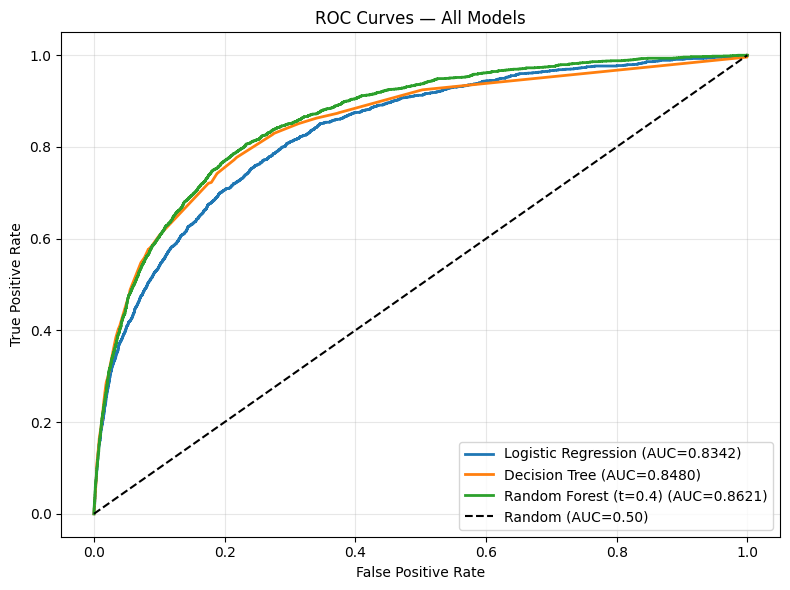

✅ ROC Curve done!


In [17]:
# Final results dictionary
final_results = {
    "Logistic Regression": {
        "model": trained_models["Logistic Regression"],
        "scaled": True
    },
    "Decision Tree": {
        "model": trained_models["Decision Tree"],
        "scaled": False
    },
    "Random Forest (t=0.4)": {
        "model": rf_better,
        "scaled": False,
        "threshold": 0.4
    }
}

# ROC Curve
plt.figure(figsize=(8,6))

for name, info in final_results.items():
    model = info["model"]
    X_input = X_test_scaled if info["scaled"] else X_test
    y_prob = model.predict_proba(X_input)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ ROC Curve done!")

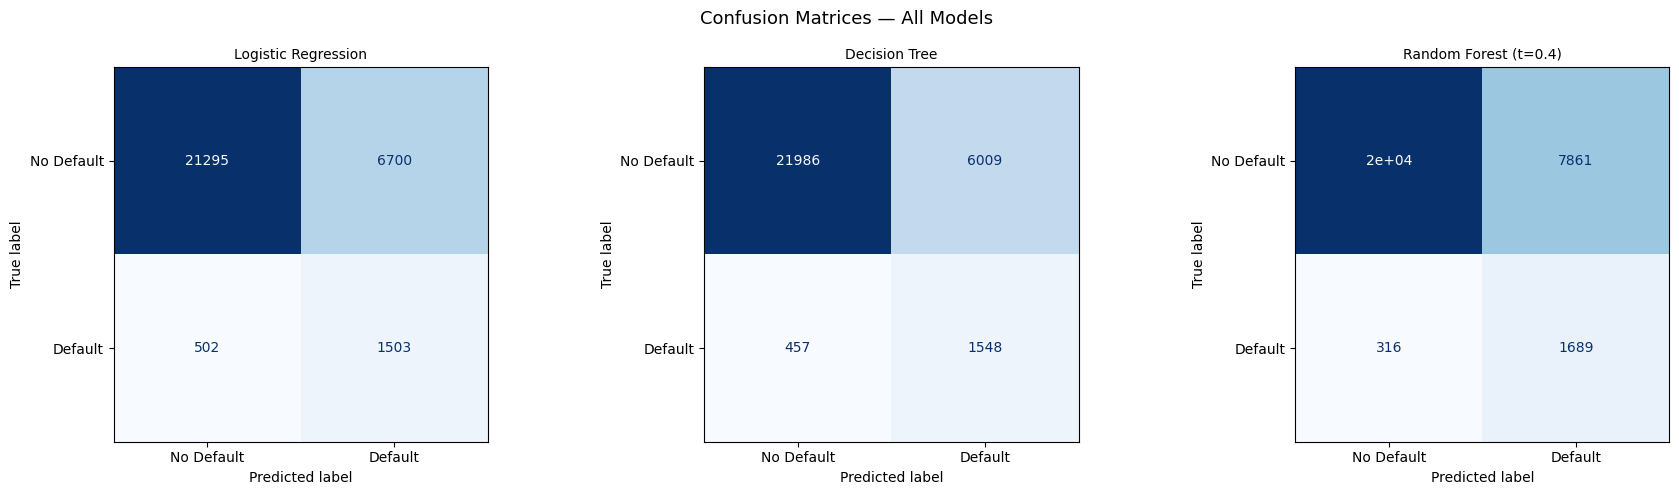

✅ Confusion matrices done!
✅ Model saved!


In [18]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, info) in zip(axes, final_results.items()):
    model = info["model"]
    X_input = X_test_scaled if info["scaled"] else X_test
    y_prob = model.predict_proba(X_input)[:, 1]
    threshold = info.get("threshold", 0.5)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Default','Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=13)
plt.tight_layout()
plt.show()
print("✅ Confusion matrices done!")

# Best Model Save karo
best_model = trained_models["Decision Tree"]
joblib.dump(best_model, 'credit_scoring_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model saved!")

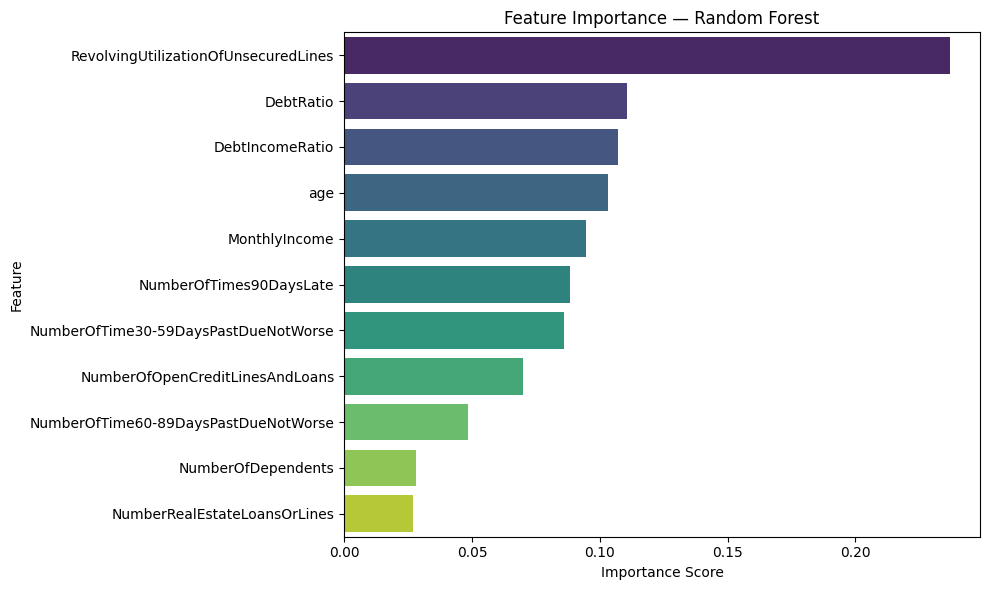


🏆 FINAL SUMMARY
  Logistic Regression  → AUC: 0.8342
  Decision Tree        → AUC: 0.8480
  Random Forest        → AUC: 0.8621 ⭐ BEST

✅ Model saved: credit_scoring_model.pkl
✅ Task 1 COMPLETE! Ready for GitHub & LinkedIn!


In [19]:
# Feature Importance
rf_model = trained_models["Random Forest"]
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*50)
print("🏆 FINAL SUMMARY")
print("="*50)
print(f"  Logistic Regression  → AUC: 0.8342")
print(f"  Decision Tree        → AUC: 0.8480")
print(f"  Random Forest        → AUC: 0.8621 ⭐ BEST")
print(f"\n✅ Model saved: credit_scoring_model.pkl")
print(f"✅ Task 1 COMPLETE! Ready for GitHub & LinkedIn!")
print("="*50)